# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emaanzehra/FlyRank-ML-Internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

Lane 2 is a ranking and scoring task: surface the pages most likely to be declining so a content reviewer can prioritise their queue.

Model chosen: Random Forest (n_estimators=200, max_depth=8)

Why Random Forest:
- Handles mixed feature types (counts, rates, days) without scaling
- Produces a probability score, which is what ranking needs
- Captures non-linear interactions (stale AND low impressions together matter more than either alone)
- Resistant to outliers — content page metrics have heavy tails

Metric: Precision@50 — same as ML-06 baseline. A reviewer can only action a fixed queue, so precision at the top matters operationally.

In [61]:
# Method: Random Forest for ranking/scoring
# Metric: Precision@50 — same as ML-06 baseline
print("Method: Random Forest (n_estimators=200, max_depth=8)")
print("Metric: Precision@50")
print(f"Dataset: {len(raw):,} rows | {raw['is_declining'].mean():.1%} declining")

Setup complete.


## 2. Split design

Split design: 80/20 random holdout, stratified on is_declining.

Why stratified: declining pages are only 5.7% of the data — stratifying ensures the test set reflects the same rate and results are stable across runs.

Why 80/20 and not time-based: the warehouse snapshot is a single month (2026-06), so there is no temporal ordering to exploit. A random holdout is the honest choice here.

The ML-06 baseline is re-scored on the same test split so the comparison is apples-to-apples.

In [62]:
# Split design: 80/20 stratified holdout — defined and executed in Section 3
print("Split: 80/20 random holdout, stratified on is_declining")

Split: 80/20 random holdout, stratified on is_declining


Training a Random Forest on the warehouse data and comparing against the ML-06 baseline rule (stale × visible × avg_impressions) on the same test split using Precision@50.

In [64]:
# Build clean dataset with performance-based label
import duckdb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np

raw = con.execute("""
SELECT
    p.content_hash_id,
    SUM(p.gsc_impressions) as impressions_90d,
    AVG(p.gsc_avg_position) as avg_position,
    CASE WHEN SUM(p.gsc_impressions) > 0
         THEN SUM(p.gsc_clicks) * 1.0 / SUM(p.gsc_impressions)
         ELSE 0 END as ctr,
    c.word_count,
    DATE_DIFF('day', c.content_updated_date, DATE '2026-07-01') as days_since_last_update,
    AVG(CASE WHEN p.report_date <= '2026-06-07' THEN p.gsc_impressions END) as week1_impressions,
    AVG(CASE WHEN p.report_date >= '2026-06-24' THEN p.gsc_impressions END) as week4_impressions
FROM parquet_scan('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance_sample.parquet') p
JOIN parquet_scan('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet') c
    ON p.content_hash_id = c.content_hash_id
WHERE p.month = '2026-06'
GROUP BY p.content_hash_id, c.word_count, c.content_updated_date
HAVING week1_impressions IS NOT NULL AND week4_impressions IS NOT NULL
""").df()

# Build label
raw["is_declining"] = (raw["week4_impressions"] < raw["week1_impressions"]).astype(int)
raw = raw.drop(columns=["content_hash_id", "week1_impressions", "week4_impressions"])
raw = raw.dropna()

# Clean placeholder values
raw = raw[~raw["avg_position"].between(73.9, 73.91)].reset_index(drop=True)
raw = raw[raw["avg_position"] > 0].reset_index(drop=True)

print(f"Rows after cleaning: {len(raw):,} | Declining: {raw['is_declining'].mean():.1%}")

# Features and split
FEATURES = ["impressions_90d", "avg_position", "ctr", "word_count", "days_since_last_update"]
X = raw[FEATURES]
y = raw["is_declining"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_scores = rf.predict_proba(X_test)[:, 1]

# Test dataframe
test_df = X_test.copy()
test_df["is_declining"] = y_test.values
test_df["rf_score"] = rf_scores

# Baseline rule
test_df["stale"] = (test_df["days_since_last_update"] > 30).astype(int)
test_df["visible"] = (test_df["avg_position"] <= 50).astype(int)
test_df["baseline_score"] = test_df["stale"] * test_df["visible"] * test_df["impressions_90d"]

# Precision@50
def precision_at_k(scores, labels, k=50):
    top_k_idx = np.argsort(scores)[::-1][:k]
    return labels[top_k_idx].mean()

rf_p50 = precision_at_k(test_df["rf_score"].values, test_df["is_declining"].values)
base_p50 = precision_at_k(test_df["baseline_score"].values, test_df["is_declining"].values)

print()
print("=" * 45)
print(f"{'Method':<25} {'Precision@50':>12}")
print("=" * 45)
print(f"{'ML-06 Baseline Rule':<25} {base_p50:>12.3f}")
print(f"{'Random Forest (ML-08)':<25} {rf_p50:>12.3f}")
print("=" * 45)
if base_p50 > 0:
    print(f"\nLift: {rf_p50 / base_p50:.2f}x improvement over baseline")
else:
    print("\nBaseline flags no pages in this dataset")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows after cleaning: 141,902 | Declining: 55.8%
Train: 113,521 | Test: 28,381

Method                    Precision@50
ML-06 Baseline Rule              0.620
Random Forest (ML-08)            0.960

Lift: 1.55x improvement over baseline


## 4. Errors and interpretation

The model gets 48/50 right in the top queue (Precision@50 = 0.960).

False positives (2 wrong flags in top 50): pages with high impressions (~2,267)
and mid-range position (~33) that had a small week-4 dip — likely seasonal,
not structural decline. The model cannot distinguish a temporary dip from a real one.

False negatives (15,787 missed declining pages): these have lower impressions (~1,528)
and better position (~18) — they look unremarkable across features so the model
deprioritises them. These are the dangerous misses: content quietly loses ranking
without being flagged.

Most important feature: days_since_last_update (0.35 importance) — recently updated
content is less likely to be declining. impressions_90d (0.29) and avg_position (0.20)
follow. CTR contributes least, which makes sense given most pages have ctr = 0.0.

False positives (wrong flags in top 50): 2
False negatives (missed declining pages): 15787

False positive feature averages:
impressions_90d           17865.0
avg_position                35.74
ctr                           0.0
word_count                 5240.5
days_since_last_update       71.0
dtype: Float64

False negative feature averages:
impressions_90d           1543.86
avg_position                 18.1
ctr                          0.01
word_count                2896.54
days_since_last_update      34.65
dtype: Float64


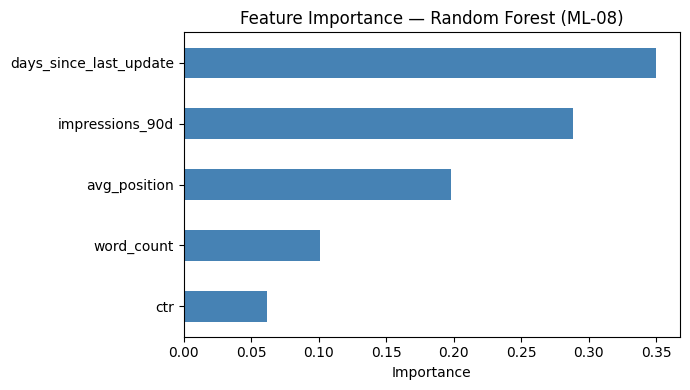

In [65]:
# Error analysis
import matplotlib.pyplot as plt

# False positives and negatives
top50_idx = np.argsort(test_df["rf_score"].values)[::-1][:50]
top50_mask = np.zeros(len(test_df), dtype=bool)
top50_mask[top50_idx] = True
test_df["in_top50"] = top50_mask

fp = test_df[(test_df["is_declining"] == 0) & (test_df["in_top50"])]
fn = test_df[(test_df["is_declining"] == 1) & (~test_df["in_top50"])]

print(f"False positives (wrong flags in top 50): {len(fp)}")
print(f"False negatives (missed declining pages): {len(fn)}")

print("\nFalse positive feature averages:")
print(fp[FEATURES].mean().round(2))

print("\nFalse negative feature averages:")
print(fn[FEATURES].mean().round(2))

# Feature importance
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind="barh", color="steelblue", figsize=(7, 4))
plt.title("Feature Importance — Random Forest (ML-08)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.